# **Задание №1. Использование глубокой сверточной нейронной сети для классификации предметов одежды на примере датасета Fashion MNIST**


**В качестве интерфейса для работы с моделями используйте [Streamlit](https://colab.research.google.com/drive/1PUvx9rGgAYSb2dZfGbzjfqRK86CLzsko#scrollTo=kSbmm9EjH5Uz)**

[Техническая документация по датасету](https://www.kaggle.com/datasets/zalando-research/fashionmnist)

## 1.1. Устанавливаем необходимые зависимости

In [1]:
# Собственно архитектура модели
from keras.models import Sequential   # Обертка для последовательности слоёв

from keras.layers import Input        # входной слой
from keras.layers import Conv2D       # Свёрточный слой
from keras.layers import MaxPooling2D # Пулинг, берет максимум из блока пикселей
from keras.layers import GlobalAveragePooling2D # Пулинг, берет максимум из блока пикселей
from keras.layers import Flatten      # Выравнивает 2D-изображение в 1D-вектор

from keras.layers import Dense        # Полносвязный слой, каждый новый связан...
                                      # с предыдущим, должен быть после Flatten...
                                      # (т.к. обрабатывает 1D-вектор)

# Оптимизаторы
# from keras.optimizers import SGD  # Градиентный спуск
from keras.optimizers import Adam # Как градиентный спуск, шаг
                                  # адаптируется автоматически

# dataset
from keras.datasets import fashion_mnist

# предобработка?
from keras.utils import to_categorical # битовая маска для классов: 1/3 - [1,0,0]...
                                       # это нужно для определения вероятностей
                                       # [0.73, 0.12, ...]

# callbacks
from keras.callbacks import ModelCheckpoint   # сохранение лучшей модели
from keras.callbacks import EarlyStopping     # Если 3 эпохи нет улучшений - останавливает обучение
from keras.callbacks import ReduceLROnPlateau # уменьшение learning rate

import matplotlib.pyplot as plt
import numpy as np

## 1.2. Разделяем данные на обучающую и тестовую выборку

In [2]:
(trainX, trainy), (testX, testy) = fashion_mnist.load_data()

print('Train: X = ', trainX.shape)
print('Test: X = ', testX.shape)

y_train_cat = to_categorical(trainy, 10)
y_test_cat = to_categorical(testy, 10)

Train: X =  (60000, 28, 28)
Test: X =  (10000, 28, 28)


## 1.3. Визуализируем часть данных из датасета

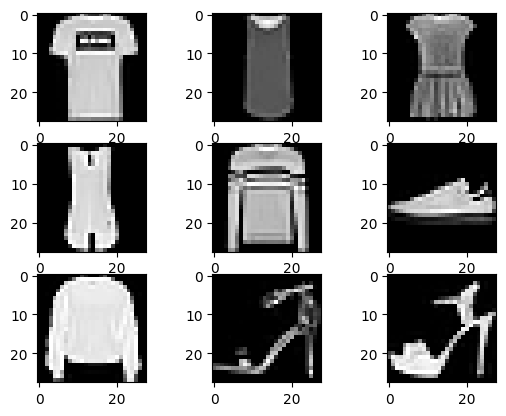

In [3]:
for i in range(1, 10):
    plt.subplot(3, 3, i) # сетка 3х3
    plt.imshow(trainX[i], cmap=plt.get_cmap('gray'))

plt.show()

## 1.4. Создаём архитектуру нейронной сети и компилируем модель

In [4]:
FILTERS_SHAPE = (3,3)       # размер фильтра
PADDING       = 'same'      # Рамка из нулей, чтобы выход был 28×28, а не 26×26
POOLING_SHAPE = (2,2)
STRIDES       = 2           # сдвигаемся на 2 → выход ровно вдвое меньше: 28×28 → 14×14
IMG_SIZE      = 28
CHANNELS      = 1

model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS)),

    # Извлечение признаков (самых мелких)
    Conv2D(filters     = 32,            # кол-во фильтров
           kernel_size = FILTERS_SHAPE,
           padding     = PADDING,
           activation  = 'relu'
    ),
    MaxPooling2D(pool_size=POOLING_SHAPE,
                 strides=STRIDES
    ),

    # Опять извлечение признаков (более сложных). Ну типа сначала низкоуровневые - линии
    # А потом - более сложные комбинации - условно: воротник, манжет и т.д.

    # Для чего увеличиваем кол-во фильтров, если изображение и так уже уменьшено после пулинга?
    # Пример:
    # Уровень 1 (буквы): а, б, в, г... — всего 33 варианта → мало фильтров
    # Уровень 2 (слова): стол, стул, диван, шкаф... — тысячи вариантов → много фильтров
    # Это я скопипасил сам для себя, Александр Сергеевич :)

    Conv2D(filters      = 64,
           kernel_size  = FILTERS_SHAPE,
           padding      = PADDING,
           activation   = 'relu'
    ),
    MaxPooling2D(pool_size=POOLING_SHAPE,
                 strides=STRIDES
    ),

    # вытягиваем в колбаску (вектор)
    # Flatten(), # тут 1568 признаков

    # Собственно классификация
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),  # сжимаем эти 1568 признаков в 128 : типа осмысливаем эти признаки
    Dense(units      = 10,  # а здесь уже жестко распределяем по 10 классам
          activation ='softmax') # cо значениями, больше похожими на вероятность [0, 1]
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,426 (111.04 KB)

 Trainable params: 28,426 (111.04 KB)

 Non-trainable params: 0 (0.00 B)

## 1.5. Обучаем модель

In [5]:
EPOCHS = 30

model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy', # формула штрафа за неверное предсказание:
                                            # берем, потому что у нас разбито по категориям
    metrics   = ['accuracy']      # точность
)

checkpoint = ModelCheckpoint(
    filepath       = 'my_first_cnn.keras',
    monitor        = 'val_accuracy', # отслеживаем точность на валидации
    save_best_only = True,
    verbose        = 1 # логи
)

early_stop = EarlyStopping(
    monitor  = 'val_loss', # Следим именно за val_loss, а не за val_accuracy —
                        # потому что loss точнее отражает реальное ухудшение.
                        # Accuracy может не меняться

    patience = 3,       # сколько эпох ждём
    restore_best_weights = True, # откатываемся к лучшим весам
    verbose  = 1
)

reduce_lr = ReduceLROnPlateau(
    monitor  ='val_loss',
    factor   = 0.5, # во сколько уменьшаем (но вообще-то правильнее увеличиваем) learning_rate
    patience = 3,
    min_lr   = 1e-6, # нижняя граница learning_rate
    verbose  = 1
)

CALLBACKS = [checkpoint, early_stop, reduce_lr]



his = model.fit(
    trainX,
    y_train_cat, # метки классов по которым надо распределить
    batch_size = 32, # обрабатываем по 32 картинки
    epochs     = EPOCHS,
    validation_split = 0.2, # 20% картинок для валидации
    callbacks  = CALLBACKS
)


model.evaluate(testX, y_test_cat) # метод evaluate() предназначен для оценки уже обученной модели с использованием данных проверки
                                   #(или тестирования) и соответствующих меток. Возвращает значение потерь и значения показателей для модели.

Epoch 1/30
1484/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6427 - loss: 1.0936
Epoch 1: val_accuracy improved from None to 0.78292, saving model to my_first_cnn.keras

Epoch 1: finished saving model to my_first_cnn.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.7461 - loss: 0.7275 - val_accuracy: 0.7829 - val_loss: 0.6011 - learning_rate: 0.0010
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8355 - loss: 0.4651
Epoch 2: val_accuracy improved from 0.78292 to 0.84517, saving model to my_first_cnn.keras

Epoch 2: finished saving model to my_first_cnn.keras
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8420 - loss: 0.4467 - val_accuracy: 0.8452 - val_loss: 0.4481 - learning_rate: 0.0010
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8602 - loss: 0.3909
Epoch 3: val_accuracy improved from 0.84517 to 0.86958, saving model to my_first_cnn.keras

Epoch 3: finished saving model to my_first_cnn.keras
1500/1500 ━━━━━━━

[0.30123499035835266, 0.894599974155426]

## 1.6. Анализируем обученную модель. Строим график (графики) обучения

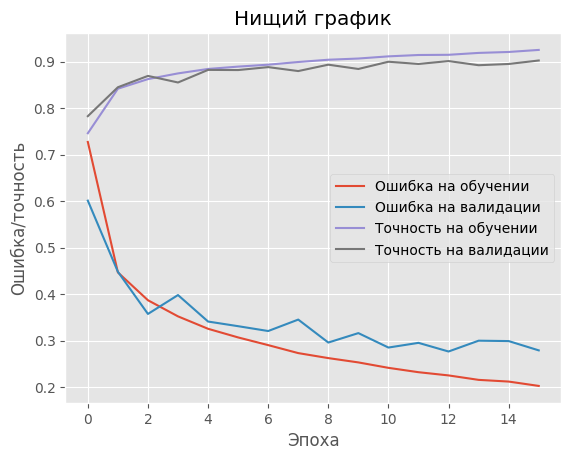

In [6]:
N = np.arange(0, len(his.history["loss"])) # массив эпох

plt.style.use("ggplot")
plt.figure()
plt.plot(N, his.history["loss"], label="Ошибка на обучении")
plt.plot(N, his.history["val_loss"], label="Ошибка на валидации")
plt.plot(N, his.history["accuracy"], label="Точность на обучении")
plt.plot(N, his.history["val_accuracy"], label="Точность на валидации")
plt.title("Нищий график")
plt.xlabel("Эпоха")
plt.ylabel("Ошибка/точность")
plt.legend()

## 1.7. Загружаем свои изображения. С помощью функции predict() получаем предсказание нейронной сети



> Требуется получить предсказания минимум по 5 изображениям, каждое из которых относится к разному классу. Не забудьте добавить метки к каждому классу (для этого можно просто создать список строк, каждая из которых будет соответствовать классу с определенным индексом см. [тех.док.](https://www.kaggle.com/datasets/zalando-research/fashionmnist)). Процент уверенности нейронной сети в своём предсказании выводить обязательно.



In [7]:
# Скачиваем архив с набором данных
!curl -L -o clothes_dataset.zip \
  https://www.kaggle.com/api/v1/datasets/download/ryanbadai/clothes-dataset


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1405M  100 1405M    0     0  82.7M      0  0:00:16  0:00:16 --:--:-- 62.7M


In [8]:
%%capture
# Распаковываем архив в папку dataset (%%capture подавляет вывод большого списка файлов)
!unzip clothes_dataset.zip -d new_dataset

In [9]:
import os
from glob import glob

base_dir = '/content/new_dataset/Clothes_Dataset'

kaggle_classes = ['Polo', 'Jeans', 'Hoodie', 'Kemeja', 'Jaket']

image_paths = []
true_labels = []

for cls in kaggle_classes:
    folder = os.path.join(base_dir, cls)
    files = sorted(glob(os.path.join(folder, '*'))) #  сортируем все файлы в папке класса
    if not files:
        continue
    image_paths.append(files[0]) # первый файл из папки
    true_labels.append(cls)      # его метка = имя папки

len(image_paths)
image_paths

['/content/new_dataset/Clothes_Dataset/Polo/001068a8-86c3-4029-a9d9-1e27015e7e64.jpg',
 '/content/new_dataset/Clothes_Dataset/Jeans/08973288-3d8b-4c07-9f2d-ce1392da54be.jpg',
 '/content/new_dataset/Clothes_Dataset/Hoodie/halfzip_hoodie_awk_1697034196_0d90db76_progressive_thumbnail.jpg',
 '/content/new_dataset/Clothes_Dataset/Kemeja/00e745c9-97d9-429d-8c3f-d3db7a2d2991.jpg',
 '/content/new_dataset/Clothes_Dataset/Jaket/jaket_bomber_reborn__audi_hita_1692870832_39a7fd4b_progressive_thumbnail.jpg']

In [10]:
from PIL import Image

def preprocess_image(path):
    img = Image.open(path).convert('L')      # в оттенки серого
    img = img.resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img).astype('float32') # в numpy-массив и в удобный для кераса тип числа
    arr = (255.0 - arr) / 255.0   # сначала инвертируем, потом нормализуем

    arr = arr.reshape(IMG_SIZE, IMG_SIZE, CHANNELS)
    return arr

X_new = np.stack([preprocess_image(p) for p in image_paths], # преобразуем каждое изображение
                 axis=0) # каждое изображение добавляется как новая строка
X_new.shape


(5, 28, 28, 1)

In [11]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

In [12]:
probs = model.predict(X_new)
pred_indices = np.argmax(probs, axis=1) # ищет максимум по строке (по классам), а не по столбцу. Берет максимальную вероятность


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 516ms/step


In [13]:
for true_label, pred_idx in zip(true_labels, pred_indices):
    print('Класс из нашего датасета:', true_label)
    print('Предсказание модели по Fashion-MNIST:', class_names[pred_idx], "\n")


Класс из нашего датасета: Polo
Предсказание модели по Fashion-MNIST: T-shirt/top 

Класс из нашего датасета: Jeans
Предсказание модели по Fashion-MNIST: Dress 

Класс из нашего датасета: Hoodie
Предсказание модели по Fashion-MNIST: T-shirt/top 

Класс из нашего датасета: Kemeja
Предсказание модели по Fashion-MNIST: Dress 

Класс из нашего датасета: Jaket
Предсказание модели по Fashion-MNIST: T-shirt/top 



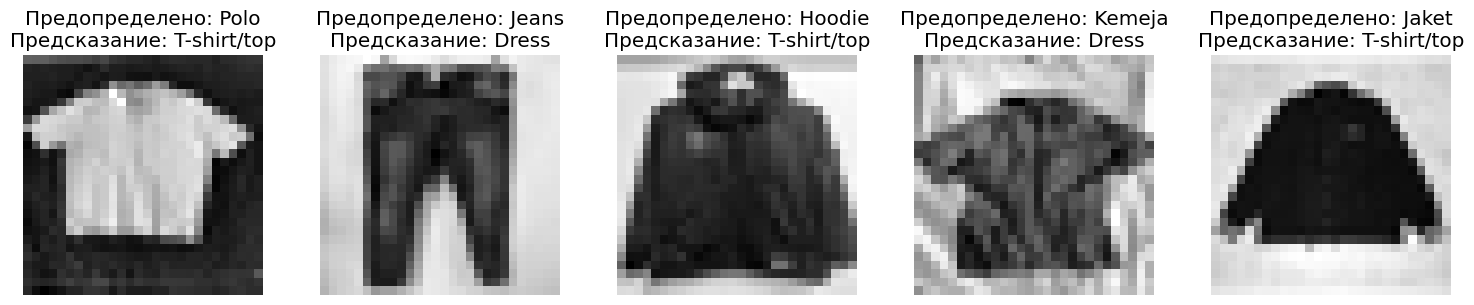

In [14]:
plt.figure(figsize=(15, 3))

for i, (path, true_label, pred_idx) in enumerate(zip(image_paths, true_labels, pred_indices)): # zip объединяет три списка в тройки (путь, истина, индекс), enumerate добавляет счётчик i для позиции subplot.
    img = Image.open(path).convert('L').resize((IMG_SIZE, IMG_SIZE)) # заново открываем оригинальную фотку
    plt.subplot(1, len(image_paths), i + 1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f'Предопределено: {true_label}\nПредсказание: {class_names[pred_idx]}')

plt.tight_layout()
plt.show()


# **Задание №2. Использование глубокой сверточной нейронной сети для классификации изображений по своему датасету**

In [15]:
!mkdir -p data
!curl -L -o data/flowers_dataset.zip "https://www.kaggle.com/api/v1/datasets/download/rahmasleam/flowers-dataset"
!unzip -q -y data/flowers_dataset.zip -d data/flowers_dataset




  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  218M  100  218M    0     0   102M      0  0:00:02  0:00:02 --:--:--  121M
UnZip 6.00 of 20 April 2009, by Debian. Original by Info-ZIP.

Usage: unzip [-Z] [-opts[modifiers]] file[.zip] [list] [-x xlist] [-d exdir]
  Default action is to extract files in list, except those in xlist, to exdir;
  file[.zip] may be a wildcard.  -Z => ZipInfo mode ("unzip -Z" for usage).

  -p  extract files to pipe, no messages     -l  list files (short format)
  -f  freshen existing files, create none    -t  test compressed archive data
  -u  update files, create if necessary      -z  display archive comment only
  -v  list verbosely/show version info       -T  timestamp archive to latest
  -x  exclude files that follow (in xlist)   -d  extract files into exdir
modifi

In [16]:
!ls data/flowers_dataset/flower_photos
DATASET_PATH = "data/flowers_dataset/flower_photos"

daisy  dandelion  roses  sunflowers  tulips


In [17]:
print(os.listdir(DATASET_PATH))  # проверь что папки есть


['roses', 'sunflowers', 'dandelion', 'daisy', 'tulips']


In [18]:
from sklearn.model_selection import train_test_split

IMG_SIZE = 128
BATCH_SIZE = 32

X, y = [], []

for idx, cls in enumerate(os.listdir(DATASET_PATH)):
    cls_folder = os.path.join(DATASET_PATH, cls)
    if not os.path.isdir(cls_folder):
        continue
    for fname in os.listdir(cls_folder):
        fpath = os.path.join(cls_folder, fname)
        try:
            img = Image.open(fpath).convert('RGB')
            img = img.resize((IMG_SIZE, IMG_SIZE))
            arr = np.array(img).astype('float32') / 255.0
            # arr = arr.reshape(IMG_SIZE, IMG_SIZE, 3)
            X.append(arr)
            y.append(idx)
        except:
            continue

X = np.array(X)
y = to_categorical(y)

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42, # сид и это оказывается мемное число
    stratify=y  # сохраняет пропорции классов
)


## 2.1.  Используя датасет, собранный для предыдущей работы, разработайте и обучите **свою** модель глубокой  **сверточной** нейронной сети для классификации изображений







In [19]:
from keras.layers import SeparableConv2D

flowers_model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    Conv2D(32, (3, 3), padding='same', activation='relu'),
    # SeparableConv2D(32, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), padding='same', activation='relu'),
    # SeparableConv2D(64, (3, 3), padding='same', activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), padding='same', activation='relu'),
    # SeparableConv2D(128, (3, 3), padding='same', activation='relu'),

    GlobalAveragePooling2D(),

    Dense(
        128,
        activation='relu',
        # kernel_regularizer=l2(1e-4)
    ),

    Dense(5, activation='softmax')
])

flowers_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,405 (431.27 KB)

 Trainable params: 110,405 (431.27 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
flowers_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint(
    "flowers_cnn_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    mode="max",
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

EPOCHS = 30

history = flowers_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint, early_stopping, reduce_lr]
)


Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2987 - loss: 1.5281
Epoch 1: val_accuracy improved from None to 0.45232, saving model to flowers_cnn_best.keras

Epoch 1: finished saving model to flowers_cnn_best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.3593 - loss: 1.4323 - val_accuracy: 0.4523 - val_loss: 1.2558 - learning_rate: 0.0010
Epoch 2/30
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4513 - loss: 1.2340
Epoch 2: val_accuracy improved from 0.45232 to 0.47820, saving model to flowers_cnn_best.keras

Epoch 2: finished saving model to flowers_cnn_best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4653 - loss: 1.2119 - val_accuracy: 0.4782 - val_loss: 1.2078 - learning_rate: 0.0010
Epoch 3/30
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5396 - loss: 1.1215
Epoch 3: val_accuracy improved from 0.47820 to 0.50272, saving model to flowers_cnn_best.keras

Epoch 3: finished saving model to flowers_cnn_best.keras
92/92 ━━

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7357 - loss: 0.7198


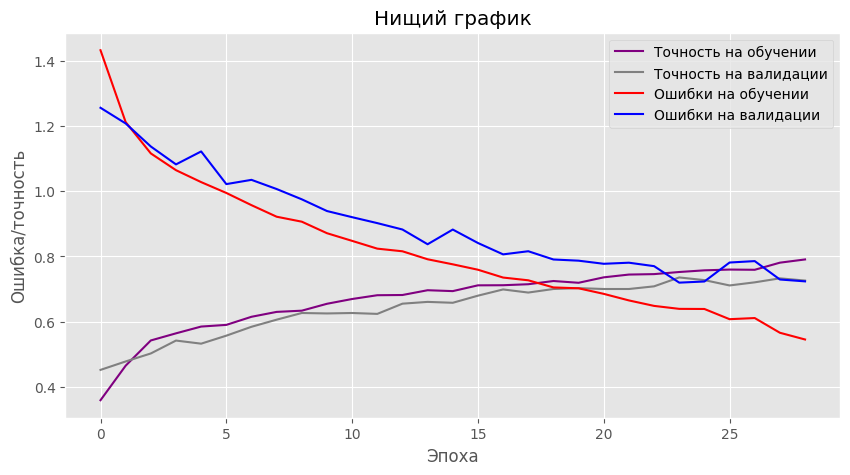

In [21]:
val_loss, val_acc = flowers_model.evaluate(X_val, y_val)


plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"],     label="Точность на обучении",  color='purple')
plt.plot(history.history["val_accuracy"], label="Точность на валидации", color='gray')
plt.plot(history.history["loss"],         label="Ошибки на обучении",    color='red')
plt.plot(history.history["val_loss"],     label="Ошибки на валидации",   color='blue')

plt.xlabel("Эпоха")
plt.ylabel("Ошибка/точность")
plt.title("Нищий график")
plt.legend()
plt.show()



## 2.2.   Ознакомьтесь с архитектурами сверточных нейронных сетей:

![Текст ссылки](https://velog.velcdn.com/images%2Fimfromk%2Fpost%2Fc04b189d-29cb-405d-93d0-b98dec818517%2Fimage.png)

На основе рассмотренных архитектур, реализуйте (частично повторяя основные паттерны проектирования) и обучите модель сверточной нейронной сети. Укажите архитектуру, которой Вы "вдохновились"

In [72]:
NUM_CLASSES = 5
IMG_SIZE = 128
alexnet = Sequential([
    Conv2D(96, kernel_size=11, strides=4, activation='relu',
           input_shape=(IMG_SIZE, IMG_SIZE, 3), padding='same'),
    MaxPooling2D(pool_size=3, strides=2),

    Conv2D(256, kernel_size=5, activation='relu', padding='same'),
    MaxPooling2D(pool_size=3, strides=2),

    Conv2D(384, kernel_size=3, activation='relu', padding='same'),

    Conv2D(384, kernel_size=3, activation='relu', padding='same'),

    Conv2D(256, kernel_size=3, activation='relu', padding='same'),
    MaxPooling2D(pool_size=3, strides=2),

    Flatten(),

    Dense(2048, activation='relu'),  # ← было 4096
    Dense(256, activation='relu'),   # ← было 4096
    Dense(NUM_CLASSES, activation='softmax')
])

alexnet.summary()


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_85 (Conv2D)              │ (None, 32, 32, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 15, 15, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ (None, 15, 15, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_53 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_87 (Conv2D)              │ (None, 7, 7, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_88 (Conv2D)              │ (None, 7, 7, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_89 (Conv2D)              │ (None, 7, 7, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 2048)           │     4,720,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,993,669 (34.31 MB)

 Trainable params: 8,993,669 (34.31 MB)

 Non-trainable params: 0 (0.00 B)

In [64]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1
    ),
    ModelCheckpoint(
        'best_alexnet.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [73]:
alexnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS = 30

history = alexnet.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)


Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.2394 - loss: 1.7359
Epoch 1: val_accuracy did not improve from 0.61444
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 65ms/step - accuracy: 0.2561 - loss: 1.6237 - val_accuracy: 0.3801 - val_loss: 1.4757 - learning_rate: 0.0010
Epoch 2/30
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3652 - loss: 1.4330
Epoch 2: val_accuracy did not improve from 0.61444
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3784 - loss: 1.3944 - val_accuracy: 0.3665 - val_loss: 1.3073 - learning_rate: 0.0010
Epoch 3/30
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4028 - loss: 1.2840
Epoch 3: val_accuracy did not improve from 0.61444
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4121 - loss: 1.2847 - val_accuracy: 0.4183 - val_loss: 1.2688 - learning_rate: 0.0010
Epoch 4/30
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4454 - loss: 1.2549
Epoch 4: val_accuracy did not improve from 0.61444
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/

In [74]:
val_loss, val_acc = alexnet.evaluate(X_val, y_val)
print(f"Validation accuracy: {val_acc:.3f}, Validation loss: {val_loss:.3f}")


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6621 - loss: 0.8961
Validation accuracy: 0.662, Validation loss: 0.896


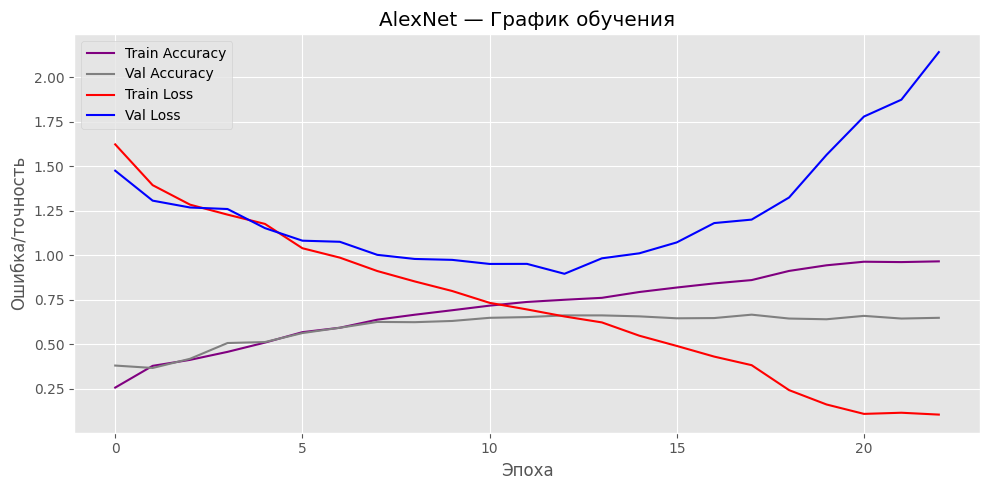

In [75]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["accuracy"], label="Train Accuracy", color='purple')
plt.plot(history.history["val_accuracy"], label="Val Accuracy", color='gray')
plt.plot(history.history["loss"], label="Train Loss", color='red')
plt.plot(history.history["val_loss"], label="Val Loss", color='blue')

plt.xlabel("Эпоха")
plt.ylabel("Ошибка/точность")
plt.title("AlexNet — График обучения")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 2.3. Сохраните полученные модели

## 2.4. Загрузите обученную модель из прошлой практической работы



## 2.5. Сравните между собой точной всех трёх моделей, подавая на вход одинаковые изображения (15 разных изображений). Сравните предсказания каждой из моделей и сделайте выводы

In [85]:
import random
import cv2
from tensorflow.keras.models import load_model

# 1. Загружаем classifier
classifier = load_model('classifier.h5')

# 2. Выборка 15 случайных изображений
all_images = glob(os.path.join(DATASET_PATH, "*", "*.*"))
random.seed(42)
sample_paths = random.sample(all_images, 15)

# 3. Маппинг классов
cnn_classes = [
    cls for cls in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, cls))
]
cnn_indices = {cls: i for i, cls in enumerate(cnn_classes)}

clf_classes = sorted([
    cls for cls in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, cls))
])
clf_indices = {cls: i for i, cls in enumerate(clf_classes)}

# 4. Загрузчики
def load_batch_cnn(paths, size):
    X, y = [], []
    for p in paths:
        cls = os.path.basename(os.path.dirname(p))
        img = Image.open(p).convert('RGB').resize(size)
        arr = np.array(img).astype('float32') / 255.0
        X.append(arr)
        y.append(cnn_indices[cls])
    return np.stack(X), np.array(y)

def load_batch_flat(paths, size=(64, 64)):
    X, y = [], []
    for p in paths:
        cls = os.path.basename(os.path.dirname(p))
        img = cv2.imread(p)              # ← BGR как при обучении!
        img = cv2.resize(img, size)
        arr = img.astype('float32') / 255.0
        arr = arr.reshape(-1)            # → (12288,)
        X.append(arr)
        y.append(clf_indices[cls])
    return np.stack(X), np.array(y)

# 5. Загружаем данные
X_flowers,    y_true_cnn = load_batch_cnn(sample_paths, flowers_model.input_shape[1:3])
X_alexnet,    _          = load_batch_cnn(sample_paths, alexnet.input_shape[1:3])
X_classifier, y_true_clf = load_batch_flat(sample_paths)

# 6. Предсказания
pred_flowers    = np.argmax(flowers_model.predict(X_flowers,    verbose=0), axis=1)
pred_alexnet    = np.argmax(alexnet.predict(X_alexnet,          verbose=0), axis=1)
pred_classifier = np.argmax(classifier.predict(X_classifier,   verbose=0), axis=1)

# 7. Точность
print(f"flowers_model accuracy : {np.mean(pred_flowers    == y_true_cnn):.3f}")
print(f"AlexNet accuracy       : {np.mean(pred_alexnet    == y_true_cnn):.3f}")
print(f"classifier accuracy    : {np.mean(pred_classifier == y_true_clf):.3f}")

# 8. Таблица сравнения
print(f"\n{'#':<3} {'файл':<25} {'истина':<12} {'flowers':<12} {'alexnet':<12} {'classifier':<12}")
print("-" * 80)
for i, path in enumerate(sample_paths):
    print(f"{i+1:<3} {os.path.basename(path)[:24]:<25} "
          f"{cnn_classes[y_true_cnn[i]]:<12} "
          f"{cnn_classes[pred_flowers[i]]:<12} "
          f"{cnn_classes[pred_alexnet[i]]:<12} "
          f"{clf_classes[pred_classifier[i]]:<12}")


flowers_model accuracy : 0.733
AlexNet accuracy       : 0.867
classifier accuracy    : 0.600

#   файл                      истина       flowers      alexnet      classifier  
--------------------------------------------------------------------------------
1   12701063955_4840594ea6_n  daisy        daisy        daisy        daisy       
2   12406418663_af20dc225f_n  roses        tulips       roses        roses       
3   8622493424_877ae35ed7.jp  roses        daisy        daisy        daisy       
4   574373182_2776669a79_n.j  tulips       tulips       tulips       roses       
5   15118397087_bfb7ea70d5_n  sunflowers   sunflowers   sunflowers   sunflowers  
6   9339697826_88c9c4dc50.jp  sunflowers   sunflowers   sunflowers   sunflowers  
7   15054752730_fcf54d475e_m  sunflowers   sunflowers   sunflowers   sunflowers  
8   16961613890_695b36aab2_m  roses        roses        tulips       tulips      
9   4588904196_3c5825c7f4.jp  tulips       tulips       tulips       tulips      
10  8

# **Задание №3. Использование глубокой сверточной нейронной сети для восстановления изображения**

## 3.1. Работа с данными

Будем работать с набором данным `fetch_olivetti_faces` из `sklearn`.

### 3.1.1. Переведите векторы в настоящие изображения из двух размерностей

In [77]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split

data, _ = fetch_olivetti_faces(return_X_y=True)
train, test = train_test_split(data, test_size=0.2, random_state=4)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [86]:
train.shape

(320, 4096)

Сейчас изображение - это вектор, имеющий размерность 4096.

In [87]:
# Ваш код здесь

train = train.reshape((train.shape[0], 64, 64))
test = test.reshape((test.shape[0], 64, 64))

test.shape

(80, 64, 64)

### 3.1.2. Отрисуйте несколько примеров

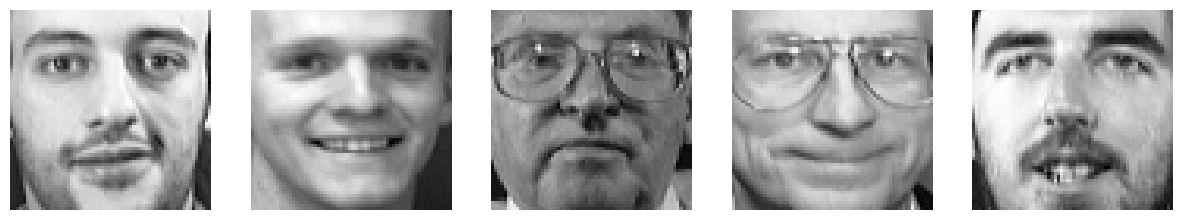

In [88]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(train[i], cmap='gray')
    ax[i].axis('off')

Поделим данные на X и y, где X - это верхняя часть лица человека, на этом модель будет обучаться, а y - это нижняя часть лица человека - её будем предсказывать.

In [89]:
n_pixels = train.shape[1]

X_train = train[:, :(n_pixels + 1) // 2, :]
y_train = train[:, n_pixels // 2:, :]


X_test = test[:, :(n_pixels + 1) // 2, :]
y_test = test[:, n_pixels // 2:, :]

In [90]:
X_train.shape

(320, 32, 64)

Вот один пример обучающей пары.

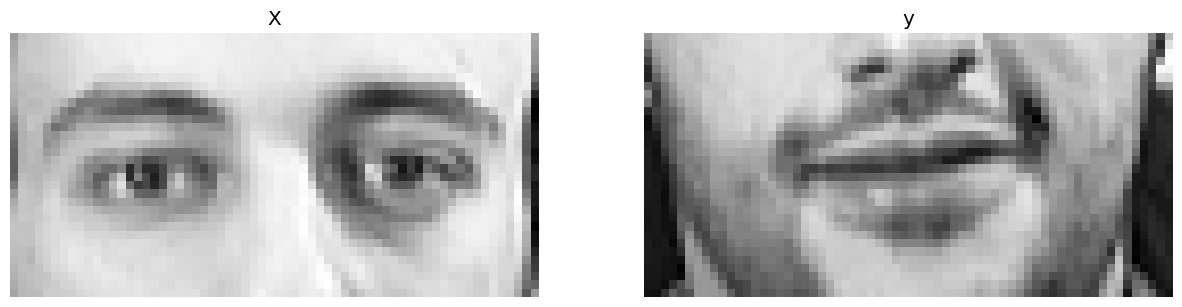

In [91]:
import matplotlib.pyplot as plt

idx = 0

fig, ax = plt.subplots(1, 2, figsize=(15, 8))
ax[0].imshow(X_train[idx], cmap='gray')
ax[0].set_title('X')
ax[1].imshow(y_train[idx], cmap='gray')
ax[1].set_title('y')
ax[0].axis('off')
ax[1].axis('off')

plt.show()

### 3.1.3. Измените размерность y
Остается только изменить размерность y, т.к. сейчас $y$ - картинка 32x64, а выход нейронной сети у нас будет одномерный и равный 32 * 64 = 2048.

In [92]:
y_train_n = y_train.reshape(y_train.shape[0], 32 * 64)
y_test_n = y_test.reshape(y_test.shape[0], 32 * 64)

y_train_n.shape

(320, 2048)

## 3.2. Создайте архитектуру для этой задачи

In [93]:
from keras.models import Sequential
from keras.layers import Flatten, Dense

faces_model = Sequential([
    Flatten(input_shape=(32, 64)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(2048, activation='sigmoid')  # 32*64 выходных пикселей
])

faces_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_17 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 2048)           │       526,336 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,706,752 (6.51 MB)

 Trainable params: 1,706,752 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

## 3.3. Скомпилируйте сеть

Подберите нужную функцию потерь и метрику. Оптимизатор можете использовать 'adam'

In [94]:

from keras.optimizers import Adam

faces_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)


## 3.4. Обучите нейросеть

Выберите нужное количество эпох.


In [95]:
EPOCHS = 100
BATCH_SIZE = 32

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5,
    verbose=1
)

history_faces = faces_model.fit(
    X_train,
    y_train_n,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0261 - mae: 0.1310 - val_loss: 0.0232 - val_mae: 0.1237 - learning_rate: 0.0010
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0212 - mae: 0.1175 - val_loss: 0.0215 - val_mae: 0.1191 - learning_rate: 0.0010
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0204 - mae: 0.1153 - val_loss: 0.0224 - val_mae: 0.1202 - learning_rate: 0.0010
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0204 - mae: 0.1148 - val_loss: 0.0210 - val_mae: 0.1180 - learning_rate: 0.0010
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0197 - mae: 0.1133 - val_loss: 0.0204 - val_mae: 0.1159 - learning_rate: 0.0010
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0191 - mae: 0.1110 - val_loss: 0.0193 - val_mae: 0.1129 - learning_rate: 0.0010
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0182 - mae: 0.1082 - val_loss: 0.0186 - val_mae: 0.1103 - learning_rate: 0.0010
Epoch 8/100
8/8 ━━━━

## 3.5. Сделайте предсказания на тестовых данных

In [99]:

preds = faces_model.predict(X_test)
print(preds.shape)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step
(80, 2048)


## 3.6. Посчитайте метрику качества на тестовых данных

In [100]:

from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_n, preds)
print(f"Mean Absolute Error (MAE) на тесте: {mae:.4f}")


Mean Absolute Error (MAE) на тесте: 0.0846


## 3.7. Преобразуйте предсказанные векторы в двумерное изображение (поменяйте их размерность)

In [101]:

pred_test = preds.reshape(preds.shape[0], 32, 64)
print("Форма pred_test:", pred_test.shape)


Форма pred_test: (80, 32, 64)


Отрисуйте все предсказания.

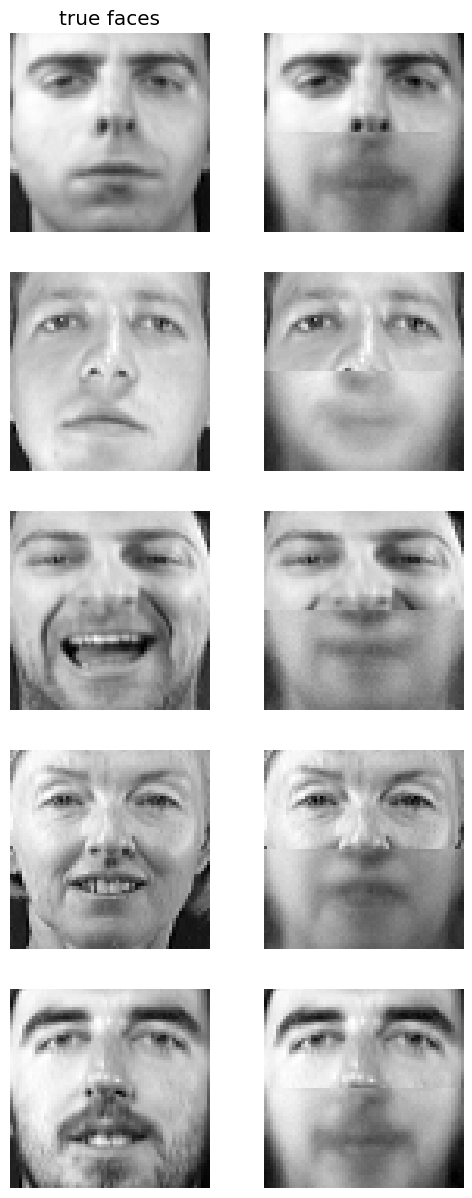

In [102]:

n_faces = 5
n_cols = 2
image_shape = (64, 64)
plt.figure(figsize=(3 * n_cols, 3 * n_faces))


for i in range(5):
    true_face = np.vstack((X_test[i], y_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1)
    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 1, title="true faces")

    sub.axis("off")
    sub.imshow(
        true_face.reshape(image_shape), cmap=plt.cm.gray, interpolation="nearest"
    )

    completed_face = np.vstack((X_test[i], pred_test[i]))

    if i:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    else:
        sub = plt.subplot(n_faces, n_cols, i * n_cols + 2)

    sub.axis("off")
    sub.imshow(
        completed_face.reshape(image_shape),
        cmap=plt.cm.gray,
        interpolation="nearest",
    )

## 3.8. Предскажите нижнюю половину лица по верхей из загруженной Вами фото (лицо на фото может быть чье угодно)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


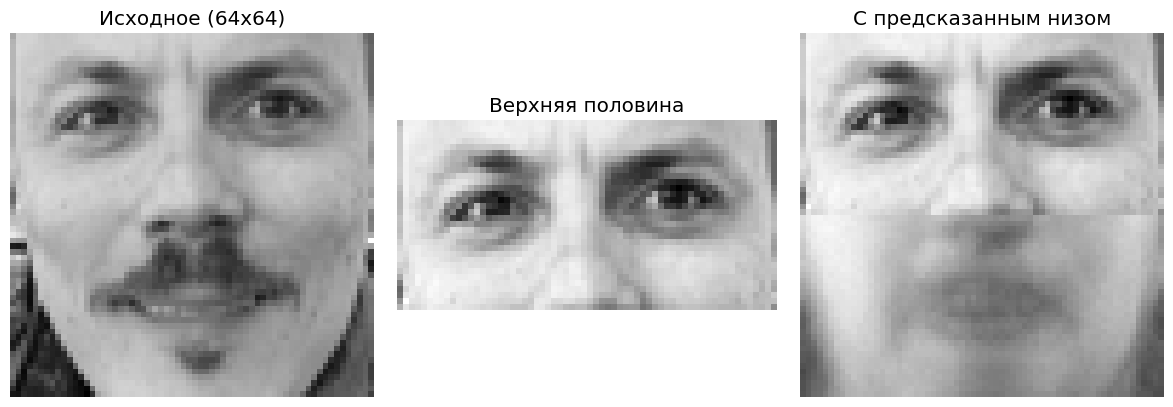

In [104]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

img_path = "/content/face.jpg"

IMGSIZE = 64

img = Image.open(img_path).convert("L")          # grayscale
img = img.resize((IMGSIZE, IMGSIZE))             # 64x64
img_arr = np.array(img).astype("float32") / 255.

upper_half = img_arr[:32, :]                     # (32, 64)
upper_half_input = upper_half.reshape(1, 32, 64) # батч из 1 картинки

pred_vec = faces_model.predict(upper_half_input)[0]   # (2048,)
pred_lower = pred_vec.reshape(32, 64)                 # (32, 64)

completed_face = np.vstack([upper_half, pred_lower])  # (64, 64)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Исходное (64x64)")
plt.imshow(img_arr, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Верхняя половина")
plt.imshow(upper_half, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("С предсказанным низом")
plt.imshow(completed_face, cmap="gray")
plt.axis("off")

plt.tight_layout()
plt.show()
